# Missing Values & Outliers — Formal Treatment

**Goal:** Move beyond ad-hoc cleaning. Treat missing values and outliers as *statistical problems* with principled solutions.

**Why it matters:** The choices you make here have more impact on model performance than the model architecture. A great model on badly preprocessed data loses to a simple model on well-preprocessed data.

**Prerequisite:** [01-data-analysis/02-data-cleaning.ipynb](../01-data-analysis/02-data-cleaning.ipynb)

**Dataset:** Titanic 

---

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)

Shape: (891, 12)


## 1. Missing Data — The Three Mechanisms

Not all missingness is the same. Statisticians classify it into three types:

| Type | Meaning | Example |
|------|---------|---------|
| **MCAR** | Missing Completely At Random | A sensor randomly dropped a reading |
| **MAR**  | Missing At Random (given other features) | Older passengers less likely to report age |
| **MNAR** | Missing Not At Random | Rich people refuse to report income |

**Why it matters:** The mechanism determines whether imputation introduces bias or not.

If missingness depends on the target (`Survived`), imputing naively = **leakage**.

## Diagnose Missingness — Is It Random?

We check whether missing values correlate with the target or other features.
If they do, missingness itself is a signal.

In [31]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

df["Age_missing"] = df["Age"].isnull().astype(int)


print("\nSurvival rate by Age-missing flag:")
print(df.groupby("Age_missing")["Survived"].mean().round(3))

print("\nSurvival rate by Cabin-missing flag:")
df["Cabin_missing"] = df["Cabin"].isnull().astype(int)
print(df.groupby("Cabin_missing")["Survived"].mean().round(3))


Columns with missing values:
Cabin       687
Age         177
Embarked      2
dtype: int64

Survival rate by Age-missing flag:
Age_missing
0    0.406
1    0.294
Name: Survived, dtype: float64

Survival rate by Cabin-missing flag:
Cabin_missing
0    0.667
1    0.300
Name: Survived, dtype: float64


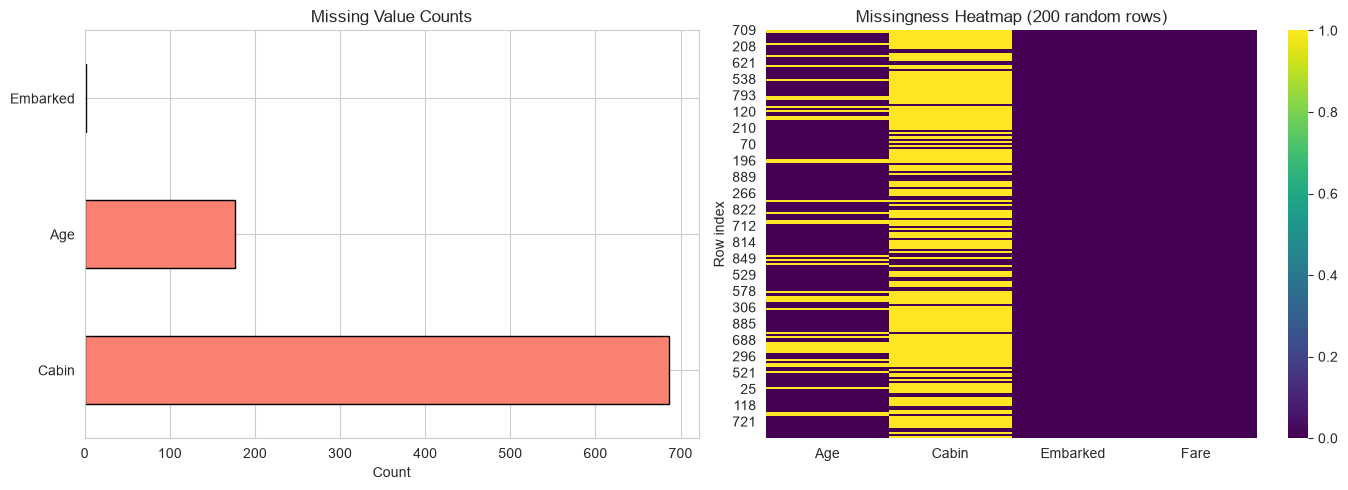

In [32]:
# Visualize missingness patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing counts
missing.plot(kind="barh", ax=axes[0], color="salmon", edgecolor="black")
axes[0].set_title("Missing Value Counts")
axes[0].set_xlabel("Count")

# Missingness heatmap (sample of rows for speed)
sample = df[["Age", "Cabin", "Embarked", "Fare"]].sample(200, random_state=42)
sns.heatmap(sample.isnull(), cbar=True, cmap="viridis", ax=axes[1])
axes[1].set_title("Missingness Heatmap (200 random rows)")
axes[1].set_ylabel("Row index")

plt.tight_layout()
plt.show()

##  Imputation Strategies — Compared

We'll compare four strategies on `Age`:

1. **Mean/Median** — simple baseline
2. **Group-wise median** — conditional on Pclass × Sex
3. **KNN Imputer** — uses similarity across features
4. **Iterative (MICE)** — models each feature as a function of others

Then we'll evaluate each by looking at the resulting distribution.

In [33]:
cols_to_drop = ["PassengerId", "Name", "Ticket", "Cabin", "Age_missing", "Cabin_missing"]
df_clean = df.drop(columns=cols_to_drop).copy()

df_encoded = pd.get_dummies(df_clean, columns=["Sex", "Embarked"], drop_first=False)

df_encoded.head(3)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True


In [34]:
# Strategy 1: simple median
df_s1 = df_encoded.copy()
age_median = df_s1["Age"].median()
df_s1["Age"] = df_s1["Age"].fillna(age_median)

print(f"Simple median: {age_median:.1f}")
print("Age std after imputation:", df_s1["Age"].std().round(2))

Simple median: 28.0
Age std after imputation: 13.02


In [35]:

df_s2 = df_clean.copy()
df_s2["Age"] = df_s2.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

print("Group medians:")
print(df_clean.groupby(["Pclass", "Sex"])["Age"].median().round(1))
print("\nAge std after group-wise imputation:", df_s2["Age"].std().round(2))

Group medians:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Age std after group-wise imputation: 13.3


In [36]:
# Strategy 3: KNN imputer — uses 5 nearest neighbors in feature space
df_s3 = df_encoded.copy()

knn = KNNImputer(n_neighbors=5)
cols_for_knn = ["Age", "Fare", "Pclass", "SibSp", "Parch",
                "Sex_female", "Sex_male",
                "Embarked_C", "Embarked_Q", "Embarked_S"]

df_s3[cols_for_knn] = knn.fit_transform(df_s3[cols_for_knn])

print("KNN imputation done.")
print("Age std after KNN:", df_s3["Age"].std().round(2))
print("Remaining missing:", df_s3[cols_for_knn].isnull().sum().sum())

KNN imputation done.
Age std after KNN: 13.61
Remaining missing: 0


In [37]:
# Strategy 4: Iterative Imputer (MICE)
# Models each feature with missing values as a function of all other features
df_s4 = df_encoded.copy()

mice = IterativeImputer(max_iter=10, random_state=42)
cols_for_mice = ["Age", "Fare", "Pclass", "SibSp", "Parch",
                 "Sex_female", "Sex_male",
                 "Embarked_C", "Embarked_Q", "Embarked_S"]

df_s4[cols_for_mice] = mice.fit_transform(df_s4[cols_for_mice])

print("MICE imputation done.")
print("Age std after MICE:", df_s4["Age"].std().round(2))
print("Remaining missing:", df_s4[cols_for_mice].isnull().sum().sum())

MICE imputation done.
Age std after MICE: 13.63
Remaining missing: 0


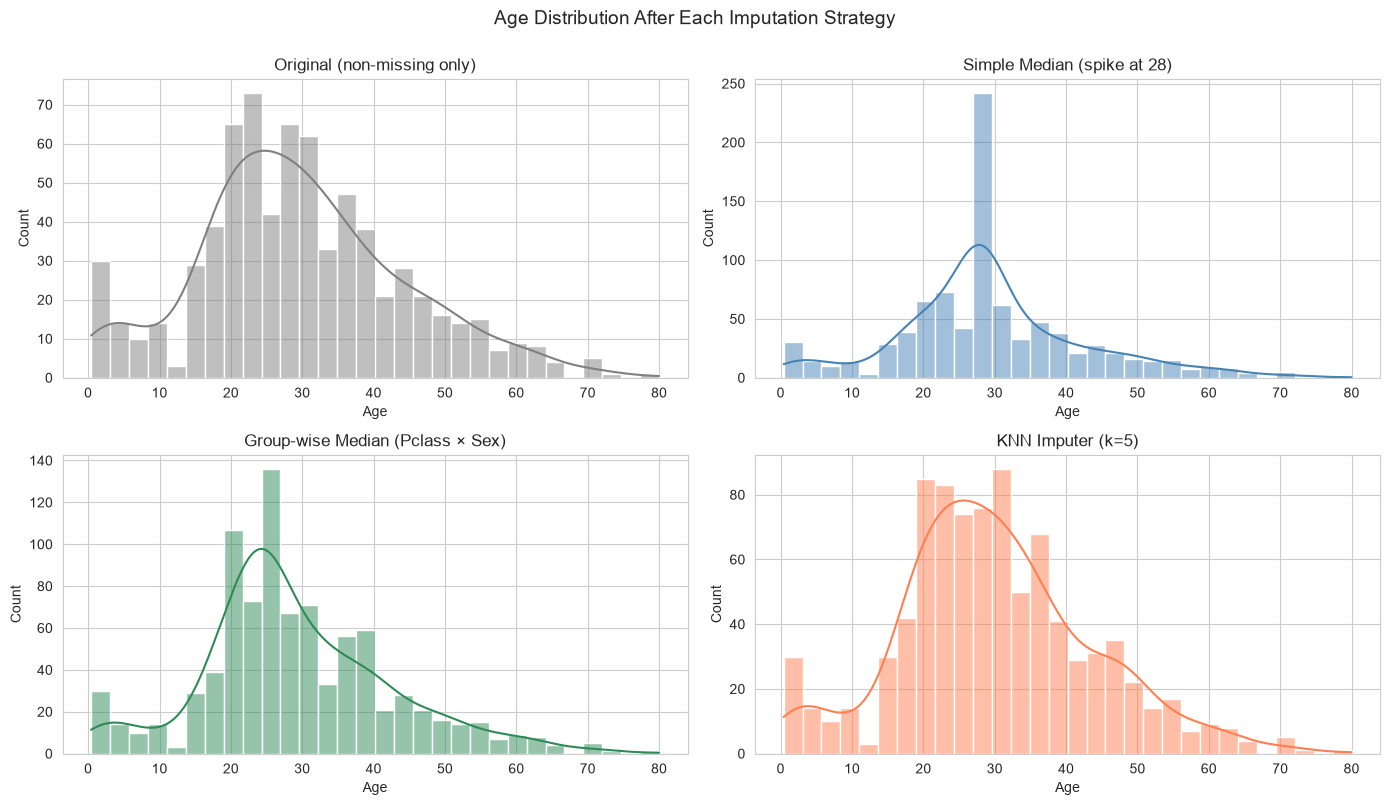

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original (only non-missing)
sns.histplot(df["Age"].dropna(), bins=30, kde=True, ax=axes[0, 0], color="gray")
axes[0, 0].set_title("Original (non-missing only)")
axes[0, 0].set_xlabel("Age")

# Strategy 1: median
sns.histplot(df_s1["Age"], bins=30, kde=True, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title(f"Simple Median (spike at {age_median:.0f})")
axes[0, 1].set_xlabel("Age")

# Strategy 2: group-wise
sns.histplot(df_s2["Age"], bins=30, kde=True, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Group-wise Median (Pclass × Sex)")
axes[1, 0].set_xlabel("Age")

# Strategy 3: KNN
sns.histplot(df_s3["Age"], bins=30, kde=True, ax=axes[1, 1], color="coral")
axes[1, 1].set_title("KNN Imputer (k=5)")
axes[1, 1].set_xlabel("Age")

plt.suptitle("Age Distribution After Each Imputation Strategy", y=1.00, fontsize=14)
plt.tight_layout()
plt.show()